In [1]:
import xarray as xr
import numpy as np
from scipy.stats import binned_statistic
import dask

import matplotlib.pyplot as plt

In [16]:
# Read NetCDF 
ds = xr.open_dataset('../dataset_gen/simu_pyqg_512_3.nc')
print(ds.q.shape) 
# Truncate along time <= 710 because after that q = 0 

ds = ds.sel(time=slice(60, 149))
print(ds.q.shape) 

# Optional: save to a new NetCDF file
#ds.to_netcdf('../data/simu_pyqg_512_3_second_run_truncated.nc')


(151, 1, 512, 512)
(90, 1, 512, 512)


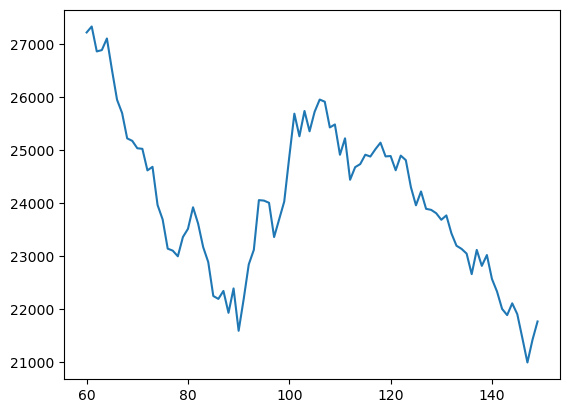

In [17]:
plt.plot(ds.time, (ds.q**2).sum(axis=(1, 2, 3)))


In [18]:
# rename dims if they are called 'x' and 'y'
ds = ds.rename({"x": "longitude", "y": "latitude"})
#ds = ds.squeeze("lev")   # removes lev if length==1

# pick the variable q
da = ds["q"]

# optional: add a var_name axis of length 1 if downstream code expects it
#da = da.expand_dims(var_name=["q"])   # remove this line if not needed

# put dims in canonical order (time, var_name, longitude, latitude)
da = da.transpose("time", "lev", "longitude", "latitude")

# clear old NetCDF encoding that can cause write issues
for k in list(da.encoding.keys()):
    if k in ("chunks", "preferred_chunks"):
        del da.encoding[k]

# chunking: keep time chunked, do not split spatially -> use full spatial size
nx = da.sizes["longitude"]; ny = da.sizes["latitude"]
da = da.chunk({"time": 1, "longitude": nx, "latitude": ny})

In [19]:
# write zarr with consolidated metadata
ds_out = da.to_dataset(name="q")
ds_out.to_zarr("../data/simu_pyqg_512_3.zarr", mode="w", consolidated=True)

In [20]:
def calc_ispec(ds, _var_dens, averaging = True, truncate=True, nd_wavenumber=False, nfactor = 1):
    """Compute isotropic spectrum `phr` from 2D spectrum of variable `signal2d`
    such that `signal2d.var() = phr.sum() * (kr[1] - kr[0])`.

    Parameters
    ----------
    model : pyqg.Model instance
        The model object from which `var_dens` originates
    
    var_dens : squared modulus of fourier coefficients like this:
        `np.abs(signal2d_fft)**2/m.M**2`

    averaging: If True, spectral density is estimated with averaging over circles,
        otherwise summation is used and Parseval identity holds

    truncate: If True, maximum wavenumber corresponds to inner circle in Fourier space,
        otherwise - outer circle
    
    nd_wavenumber: If True, wavenumber is nondimensional: 
        minimum wavenumber is 1 and corresponds to domain length/width,
        otherwise - wavenumber is dimensional [m^-1]

    nfactor: width of the bin in sqrt(dk^2+dl^2) units

    Returns
    -------
    kr : array
        isotropic wavenumber
    phr : array
        isotropic spectrum
    """

    # account for complex conjugate
    var_dens = np.copy(_var_dens)
    var_dens[...,0] /= 2
    var_dens[...,-1] /= 2

    M = ds.q.shape[3]
    
    ll = np.fft.fftfreq(M) * M
    kk = np.arange(0, M//2 + 1)
    dk = dl = 1
    k2d, l2d = np.meshgrid(kk, ll)
    wv = np.sqrt(k2d**2 + l2d**2)
 

    ll_max = np.abs(ll).max()
    kk_max = np.abs(kk).max()

    if truncate:
        kmax = np.minimum(ll_max, kk_max)
    else:
        kmax = np.sqrt(ll_max**2 + kk_max**2)
    
    kmin = 0

    dkr = np.sqrt(dk**2 + dl**2) * nfactor

    # left border of bins
    kr = np.arange(kmin, kmax, dkr)
    
    phr = np.zeros(kr.size)

    for i in range(kr.size):
        if i == kr.size-1:
            fkr = (wv>=kr[i]) & (wv<=kr[i]+dkr)
        else:
            fkr = (wv>=kr[i]) & (wv<kr[i+1])
        if averaging:
            phr[i] = var_dens[fkr].mean() * (kr[i]+dkr/2) * np.pi / (dk * dl)
        else:
            phr[i] = var_dens[fkr].sum() / dkr

        phr[i] *= 2 # include full circle
    
    # convert left border of the bin to center
    kr = kr + dkr/2

    # convert to non-dimensional wavenumber 
    # preserving integral over spectrum
    if nd_wavenumber:
        kr = kr / kmin
        phr = phr * kmin

    return kr, phr

In [21]:
# physical parameters (tuned by me)
f = 1.5e-4
L = 1100 * 1e3 
Ro = 0.011607
N = 30 * f

g = 9.80665
rho0 = 1000
alpha = 0.25 
U = Ro * f * L

def compute_ds_spec(ds): 
    # Input
    q_field = ds.isel(time=-1).q  # shape (1, M, M) or (M, M)
    M = q_field.shape[-1]
    
    # 2D FFT (real) and power spectrum
    vovo = np.fft.rfft2(q_field)
    ener_spec = np.abs(vovo)**2 / M**2  # shape (1, M, M//2 +1)
    ener_spec_squeezed = ener_spec.squeeze()  # shape (M, M//2 +1)
    
    # Compute isotropic spectrum
    kr, enstrophy_iso = calc_ispec(ds, ener_spec_squeezed)
    # rescale spectrum: [ E(k) ] = U^2 * K = U^2 * L 
    enstrophy_iso= enstrophy_iso * U**2 / (L) # rescaling  
    kr = kr / (L) # rescaling in m-1
    return kr, enstrophy_iso

In [22]:
ds = xr.open_dataset('../dataset_gen/simu_pyqg_512_3.nc')
kr, spec = compute_ds_spec(ds) 

(1e-07, 0.01)

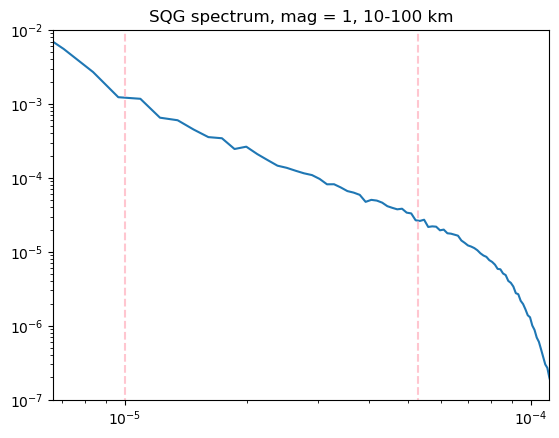

In [23]:
plt.loglog(kr, spec) 
plt.title("SQG spectrum, mag = 1, 10-100 km")

plt.xlim(1/(150*1000), 1/(9*1000))
plt.vlines(1/(19*1000), 1e-8,1e11, colors="pink", alpha=0.9, linestyles='--')
plt.vlines(1/(100*1000), 1e-8,1e11, colors="pink", alpha=0.9, linestyles='--')

plt.ylim(1e-7,1e-2)